# WhoDunIt Dataset Explorer

Visualize and inspect samples from the [kjgpta/WhoDunIt](https://huggingface.co/datasets/kjgpta/WhoDunIt) dataset.

In [31]:
import ast
from pathlib import Path
from textwrap import shorten

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("..") / "data" / "whodunit"

train = pd.read_parquet(DATA_DIR / "train.parquet")
test = pd.read_parquet(DATA_DIR / "test.parquet")

df = pd.concat([train.assign(split="train"), test.assign(split="test")], ignore_index=True)
print(f"Total rows: {len(df)}  (train={len(train)}, test={len(test)})")
df.head(3)

Total rows: 400  (train=320, test=80)


,title,author,length,culprit_ids,text,metadata,split
0,The D'Arblay Mystery,Dorothy L. Sayers,250,"['thorndyke gray', 'dewsnep']",The D’Arblay Mystery by R. Austin Freeman CONT...,{'entity_replacement_style': 'REPLACE_ALL CHAR...,train
1,The Final Problem,Arthur Conan Doyle,14,['slytherin'],It is with a heavy heart that I take up my pen...,{'entity_replacement_style': 'REPLACE_HARRY PO...,train
2,The Adventure of the Blue Carbuncle,Arthur Conan Doyle,14,['saldana barrymore'],I had called upon my friend D'arcy Blunt upon ...,{'entity_replacement_style': 'REPLACE_HOLLYWOO...,train


## Basic statistics

In [32]:
df["text_len"] = df["text"].str.len()
df["culprit_list"] = df["culprit_ids"].apply(ast.literal_eval)
df["num_culprits"] = df["culprit_list"].str.len()

df[["title", "author", "length", "text_len", "num_culprits"]].describe()

,length,text_len,num_culprits
count,400.00000,4.000000e+02,400.000000
mean,115.01250,2.289430e+05,1.162500
std,113.34286,2.336976e+05,0.401868
min,10.00000,6.509000e+03,1.000000
25%,15.75000,4.348875e+04,1.000000
50%,23.50000,6.034500e+04,1.000000
75%,208.50000,4.025522e+05,1.000000
max,430.00000,1.130886e+06,3.000000


## Stories per author

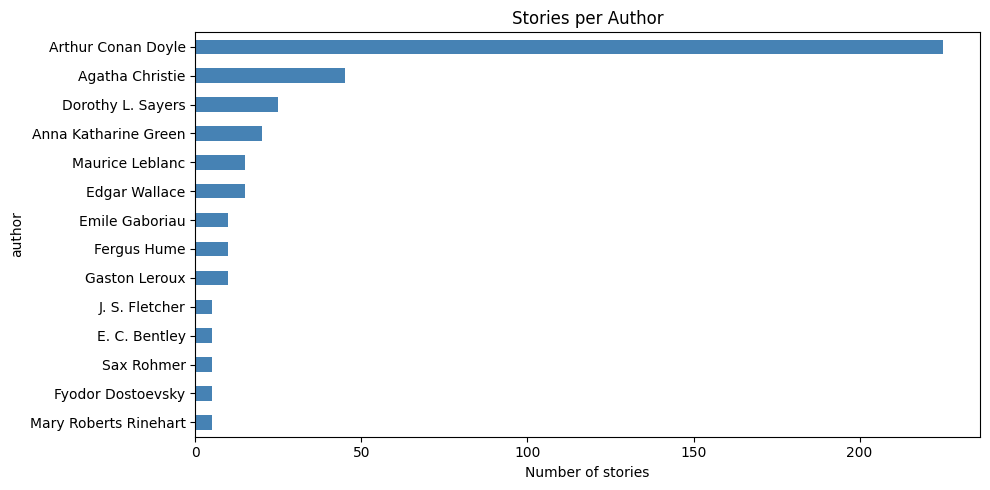

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
author_counts = df["author"].value_counts()
author_counts.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Number of stories")
ax.set_title("Stories per Author")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Distribution of story length (pages) and text length (characters)

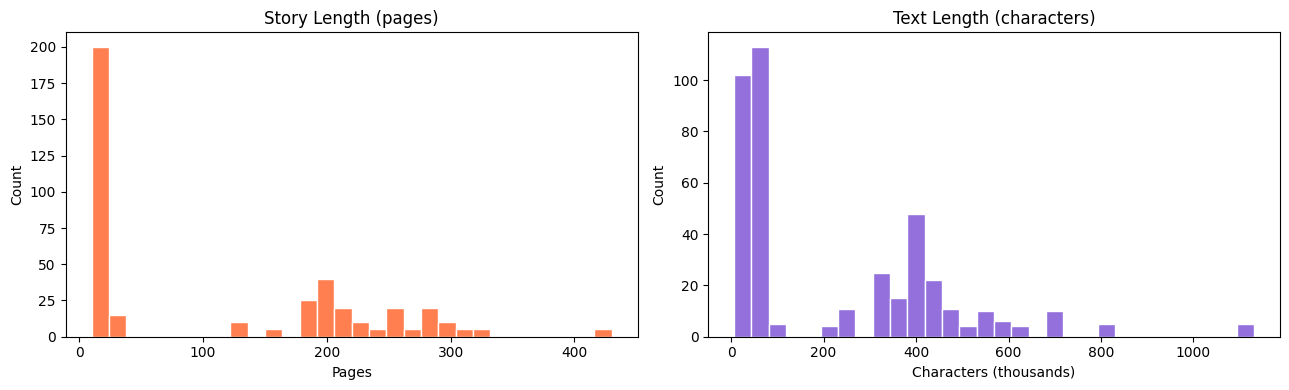

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["length"], bins=30, color="coral", edgecolor="white")
axes[0].set_xlabel("Pages")
axes[0].set_ylabel("Count")
axes[0].set_title("Story Length (pages)")

axes[1].hist(df["text_len"] / 1000, bins=30, color="mediumpurple", edgecolor="white")
axes[1].set_xlabel("Characters (thousands)")
axes[1].set_ylabel("Count")
axes[1].set_title("Text Length (characters)")

plt.tight_layout()
plt.show()

## Number of culprits per story

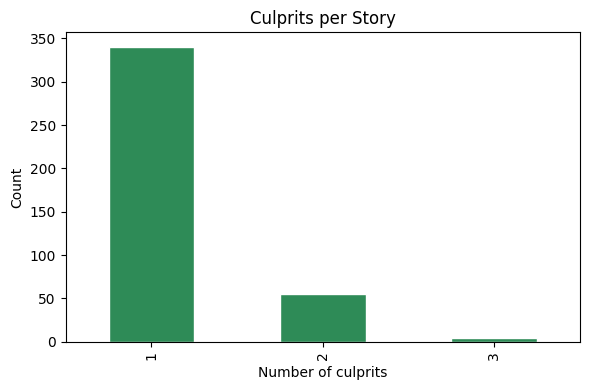

In [35]:
fig, ax = plt.subplots(figsize=(6, 4))
culprit_dist = df["num_culprits"].value_counts().sort_index()
culprit_dist.plot.bar(ax=ax, color="seagreen", edgecolor="white")
ax.set_xlabel("Number of culprits")
ax.set_ylabel("Count")
ax.set_title("Culprits per Story")
plt.tight_layout()
plt.show()

## Entity replacement styles used in augmentation

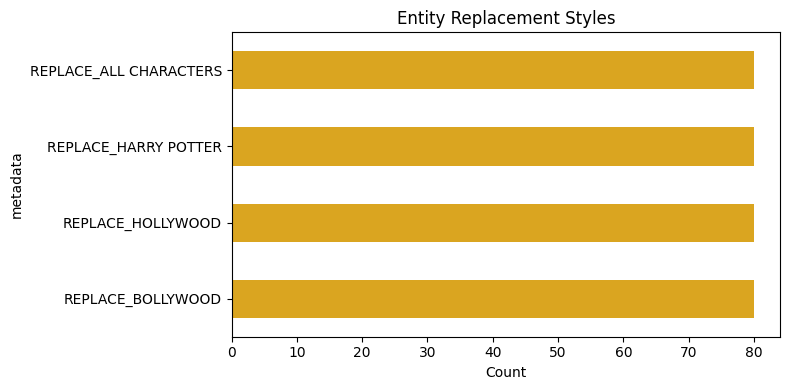

In [36]:
meta = df["metadata"].dropna().apply(ast.literal_eval)
replacement_styles = meta.apply(lambda m: m.get("entity_replacement_style", "unknown"))

fig, ax = plt.subplots(figsize=(8, 4))
replacement_styles.value_counts().plot.barh(ax=ax, color="goldenrod")
ax.set_xlabel("Count")
ax.set_title("Entity Replacement Styles")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Pages vs text length, colored by author

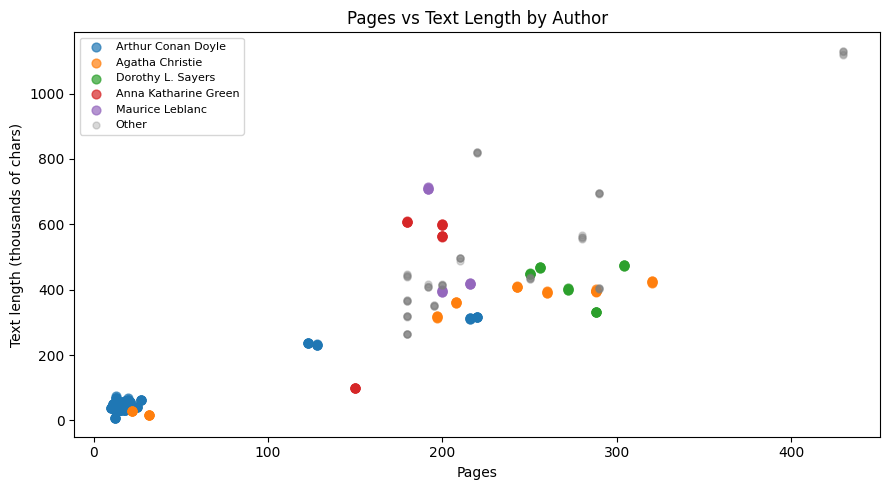

In [37]:
top_authors = df["author"].value_counts().head(5).index.tolist()
cmap = plt.colormaps["tab10"]

fig, ax = plt.subplots(figsize=(9, 5))
for i, author in enumerate(top_authors):
    subset = df[df["author"] == author]
    ax.scatter(
        subset["length"],
        subset["text_len"] / 1000,
        label=author,
        alpha=0.7,
        color=cmap(i),
        s=40,
    )

other = df[~df["author"].isin(top_authors)]
ax.scatter(other["length"], other["text_len"] / 1000, label="Other", alpha=0.3, color="gray", s=25)

ax.set_xlabel("Pages")
ax.set_ylabel("Text length (thousands of chars)")
ax.set_title("Pages vs Text Length by Author")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## Sample story snippets

A quick look at the opening text and culprit IDs for a few random samples.

In [38]:
samples = df.sample(5, random_state=42)

for _, row in samples.iterrows():
    snippet = shorten(row["text"], width=500, placeholder=" [...]")
    print(f"{'=' * 80}")
    print(f"Title:    {row['title']}")
    print(f"Author:   {row['author']}")
    print(f"Pages:    {row['length']}   |   Chars: {row['text_len']:,}")
    print(f"Culprits: {row['culprit_ids']}")
    print(f"Split:    {row['split']}")
    print(f"\n{snippet}\n")

Title:    The Adventure of the Dying Detective
Author:   Arthur Conan Doyle
Pages:    15   |   Chars: 31,380
Culprits: ['savage al']
Split:    train

Produced by Brannan Haines. HTML version by George Doyle. The Adventure of the Dying Detective By Sir Homes David Mrs. Smith, the landlady of Hudson Arthur, was a long-suffering woman. Not only was her first-floor flat invaded at all hours by throngs of singular and often undesirable characters but her remarkable lodger showed an eccentricity and irregularity in his life which must have sorely tried her patience. His incredible untidiness, his addiction to music at strange hours, his [...]

Title:    The Musgrave Ritual
Author:   Arthur Conan Doyle
Pages:    15   |   Chars: 44,863
Culprits: ['Richard Brunton', 'Rachel Howells']
Split:    train

An anomaly which often struck me in the character of my friend Sherlock Holmes was that, although in his methods of thought he was the neatest and most methodical of mankind, and although also he a

## Unique titles per split

In [39]:
for split in ["train", "test"]:
    titles = df[df["split"] == split]["title"].unique()
    print(f"{split}: {len(titles)} unique titles")

overlap = set(train["title"].unique()) & set(test["title"].unique())
print(f"\nTitles appearing in both splits: {len(overlap)}")
if overlap:
    for t in sorted(overlap):
        print(f"  - {t}")

train: 78 unique titles
test: 54 unique titles

Titles appearing in both splits: 54
  - A Case of Identity
  - A Study in Scarlet
  - Crime and Punishment
  - Find the Woman
  - Silver Blaze
  - The Adventure of Black Peter
  - The Adventure of Shoscombe Old Place
  - The Adventure of Wisteria Lodge
  - The Adventure of the Abbey Grange
  - The Adventure of the Beryl Coronet
  - The Adventure of the Bruce-Partington Plans
  - The Adventure of the Cardboard Box
  - The Adventure of the Dancing Men
  - The Adventure of the Dying Detective
  - The Adventure of the Egyptian Tomb
  - The Adventure of the Engineerâ€™s Thumb
  - The Adventure of the Golden Pince-Nez
  - The Adventure of the Illustrious Client
  - The Adventure of the Mazarin Stone
  - The Adventure of the Norwood Builder
  - The Adventure of the Priory School
  - The Adventure of the Red Circle
  - The Adventure of the Six Napoleons
  - The Adventure of the Sussex Vampire
  - The Adventure of the Three Garridebs
  - The Borou

In [44]:
import json

INDEX = 181  # <-- change this to pick a different story

row = df.iloc[INDEX]
meta_raw = row["metadata"]
meta_dict = ast.literal_eval(meta_raw) if isinstance(meta_raw, str) else meta_raw

out_dir = Path("..") / "data" / "samples"
out_dir.mkdir(parents=True, exist_ok=True)

slug = row["title"].lower().replace(" ", "_").replace("'", "")[:60]
out_path = out_dir / f"{INDEX}_{slug}.md"

lines = [
    f"# {row['title']}",
    "",
    "| Field | Value |",
    "|-------|-------|",
    f"| **Author** | {row['author']} |",
    f"| **Pages** | {row['length']} |",
    f"| **Culprits** | {row['culprit_ids']} |",
    f"| **Split** | {row['split']} |",
    "| **meta_data** | see JSON below |",
    "",
    "## meta_data",
    "",
    "```json",
    json.dumps({"meta_data": meta_dict}, indent=2),
    "```",
    "",
    "---",
    "",
    "## Full Text",
    "",
    row["text"],
] 

out_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Saved story at index {INDEX} to {out_path.resolve()}")
print(f"  Title:    {row['title']}")
print(f"  Culprits: {row['culprit_ids']}")
print(f"  Length:   {row['text_len']:,} chars")

Saved story at index 181 to /Users/taksu/Documents/Projects/mistry-game/procedural_gen/data/samples/181_the_hunters_lodge_case.md
  Title:    The Hunter's Lodge Case
  Culprits: ['zoe havering']
  Length:   17,937 chars
